# Unit06 Example 06 - 綜合化工製程流程物料平衡

## 學習目標

在本範例中，我們將探討一個完整的化工製程系統，整合反應、分離、混合、回流等多個單元操作。透過建立全製程的物料平衡方程組，處理包含循環流與分流的複雜系統，並應用 NumPy 與 SciPy 的求解工具來計算各股流的流率與組成分布。

學習完本範例後，您將能夠：

- 建立包含多個單元操作的綜合化工製程物料平衡方程式
- 處理循環流（recycle）與分流（split）的物料平衡問題
- 將複雜製程問題轉化為標準矩陣形式
- 使用 NumPy 與 SciPy 求解大型線性方程組
- 進行製程效率分析與敏感度分析

## 內容大綱

1. 環境設定與套件載入
2. 問題描述與數學模型建立
3. 建立線性方程組
4. NumPy 求解方法
5. SciPy 求解方法
6. 結果驗證與分析
7. 製程效率計算
8. 敏感度分析
9. 視覺化呈現
10. 總結

---
## 1. 環境設定與套件載入

In [14]:
# 基礎套件
import numpy as np
import matplotlib.pyplot as plt

# SciPy 線性代數模組
from scipy import linalg

# 設定 NumPy 顯示選項
np.set_printoptions(precision=4, suppress=True)

# 設定 Matplotlib 繪圖樣式
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.unicode_minus'] = False

print("="*70)
print("環境設定與套件載入")
print("="*70)
print(f"NumPy 版本: {np.__version__}")
import scipy
print(f"SciPy 版本: {scipy.__version__}")
print("="*70)

環境設定與套件載入
NumPy 版本: 1.23.5
SciPy 版本: 1.15.2


---
## 2. 問題描述與製程配置

### 2.1 化工情境

某化工廠生產高價值化學品 P（Product），採用連續操作的製程系統。原料 A 與 B 在反應器中進行化學反應生成產品 P 與副產物 W（Waste）。反應後的混合物經過分離單元，將產品 P 純化並回收未反應的原料進行循環利用。

**化學反應**：

$$
2A + B \rightarrow P + W
$$

**製程流程包含**：

1. **混合器（Mixer）**：將新鮮進料與循環流混合
2. **反應器（Reactor）**：進行化學反應（60% 轉化率）
3. **分離器（Separator）**：將產品與未反應物分離
4. **分流器（Splitter）**：將未反應物循環（80%）或排放（20%）

**操作參數**：
- 新鮮進料 A：100 kmol/h（純 A）
- 新鮮進料 B：60 kmol/h（純 B）
- 反應轉化率（基於 A）：60%
- 回流比：80%

In [15]:
# 定義製程參數
print("="*70)
print("綜合化工製程流程物料平衡問題")
print("="*70)

# 新鮮進料
F1 = 100.0  # 新鮮進料 A (kmol/h)
F2 = 60.0   # 新鮮進料 B (kmol/h)

# 反應器參數
X_A = 0.60  # 反應轉化率（基於 A）

# 分離器分離效率
alpha_P = 0.95  # 產品 P 進入產品流的比例
alpha_W = 0.90  # 副產物 W 進入產品流的比例
alpha_A = 0.02  # 未反應物 A 進入產品流的比例（其餘進入回收流）
alpha_B = 0.02  # 未反應物 B 進入產品流的比例

# 分流器參數
R = 0.80    # 回流比（循環流/總分流）

print(f"\n新鮮進料:")
print(f"  F1 (Feed A) = {F1:.1f} kmol/h")
print(f"  F2 (Feed B) = {F2:.1f} kmol/h")
print(f"\n反應器:")
print(f"  轉化率 X_A = {X_A:.1%}")
print(f"  反應式: 2A + B → P + W")
print(f"\n分離器效率:")
print(f"  產品 P → 產品流: {alpha_P:.1%}")
print(f"  副產物 W → 產品流: {alpha_W:.1%}")
print(f"  未反應物 A → 回收流: {(1-alpha_A):.1%}")
print(f"  未反應物 B → 回收流: {(1-alpha_B):.1%}")
print(f"\n分流器:")
print(f"  回流比 R = {R:.1%}")
print(f"  排放比 = {(1-R):.1%}")
print("="*70)

綜合化工製程流程物料平衡問題

新鮮進料:
  F1 (Feed A) = 100.0 kmol/h
  F2 (Feed B) = 60.0 kmol/h

反應器:
  轉化率 X_A = 60.0%
  反應式: 2A + B → P + W

分離器效率:
  產品 P → 產品流: 95.0%
  副產物 W → 產品流: 90.0%
  未反應物 A → 回收流: 98.0%
  未反應物 B → 回收流: 98.0%

分流器:
  回流比 R = 80.0%
  排放比 = 20.0%


---
## 3. 建立線性方程組

### 3.1 未知數選擇

**完整模型**：為正確處理循環流中的 P 和 W，我們選擇以下 12 個未知數：

$$
\mathbf{x} = \begin{bmatrix}
F_{3,A} \\ F_{3,B} \\ F_{3,P} \\ F_{3,W} \\ F_{4,A} \\ F_{4,B} \\ F_{4,P} \\ F_{4,W} \\ F_{6,A} \\ F_{6,B} \\ F_{6,P} \\ F_{6,W}
\end{bmatrix}
$$

其中：
- $F_{3,A}, F_{3,B}, F_{3,P}, F_{3,W}$ ：反應器進料中各成分的流率
- $F_{4,A}, F_{4,B}, F_{4,P}, F_{4,W}$ ：反應器出口中各成分的流率
- $F_{6,A}, F_{6,B}, F_{6,P}, F_{6,W}$ ：分離器未反應物流中各成分的流率

### 3.2 方程式建立

**方程式 1-4：混合器物料平衡**
- $F_{3,A} - 0.80 \times F_{6,A} = 100$ （成分 A）
- $F_{3,B} - 0.80 \times F_{6,B} = 60$ （成分 B）
- $F_{3,P} - 0.80 \times F_{6,P} = 0$ （成分 P，來自循環流）
- $F_{3,W} - 0.80 \times F_{6,W} = 0$ （成分 W，來自循環流）

**方程式 5-8：反應器物料平衡（含反應）**
- $F_{4,A} - 0.40 \times F_{3,A} = 0$ （A 的轉化）
- $F_{4,B} - F_{3,B} + 0.30 \times F_{3,A} = 0$ （B 的消耗）
- $F_{4,P} - F_{3,P} - 0.30 \times F_{3,A} = 0$ （P 的生成，含進料中的 P）
- $F_{4,W} - F_{3,W} - 0.30 \times F_{3,A} = 0$ （W 的生成，含進料中的 W）

**方程式 9-12：分離器物料平衡**
- $F_{6,A} - 0.98 \times F_{4,A} = 0$ （A 的分配）
- $F_{6,B} - 0.98 \times F_{4,B} = 0$ （B 的分配）
- $F_{6,P} - 0.05 \times F_{4,P} = 0$ （P 的分配）
- $F_{6,W} - 0.10 \times F_{4,W} = 0$ （W 的分配）

In [16]:
# 建立係數矩陣 A 與常數向量 b（完整模型）

# 未知數順序: [F_3A, F_3B, F_3P, F_3W, F_4A, F_4B, F_4P, F_4W, F_6A, F_6B, F_6P, F_6W]

# 初始化 12x12 係數矩陣與常數向量
A = np.zeros((12, 12))
b = np.zeros(12)

# 方程式 1: 混合器成分 A 平衡
# F_3A - R*F_6A = F1
A[0, 0] = 1.0      # F_3A 係數
A[0, 8] = -R       # F_6A 係數
b[0] = F1

# 方程式 2: 混合器成分 B 平衡
# F_3B - R*F_6B = F2
A[1, 1] = 1.0      # F_3B 係數
A[1, 9] = -R       # F_6B 係數
b[1] = F2

# 方程式 3: 混合器成分 P 平衡（新增）
# F_3P - R*F_6P = 0
A[2, 2] = 1.0      # F_3P 係數
A[2, 10] = -R      # F_6P 係數
b[2] = 0

# 方程式 4: 混合器成分 W 平衡（新增）
# F_3W - R*F_6W = 0
A[3, 3] = 1.0      # F_3W 係數
A[3, 11] = -R      # F_6W 係數
b[3] = 0

# 方程式 5: 反應器成分 A 平衡
# F_4A - (1-X_A)*F_3A = 0
A[4, 0] = -(1 - X_A)  # F_3A 係數
A[4, 4] = 1.0         # F_4A 係數
b[4] = 0

# 方程式 6: 反應器成分 B 平衡
# F_4B - F_3B + (X_A/2)*F_3A = 0
A[5, 0] = X_A / 2     # F_3A 係數（消耗量）
A[5, 1] = -1.0        # F_3B 係數
A[5, 5] = 1.0         # F_4B 係數
b[5] = 0

# 方程式 7: 反應器產品 P 平衡（修改：考慮進料中的 P）
# F_4P - F_3P - (X_A/2)*F_3A = 0
A[6, 0] = -X_A / 2    # F_3A 係數（生成量）
A[6, 2] = -1.0        # F_3P 係數（進料中的 P）
A[6, 6] = 1.0         # F_4P 係數
b[6] = 0

# 方程式 8: 反應器副產物 W 平衡（修改：考慮進料中的 W）
# F_4W - F_3W - (X_A/2)*F_3A = 0
A[7, 0] = -X_A / 2    # F_3A 係數（生成量）
A[7, 3] = -1.0        # F_3W 係數（進料中的 W）
A[7, 7] = 1.0         # F_4W 係數
b[7] = 0

# 方程式 9: 分離器成分 A 分配
# F_6A - (1-alpha_A)*F_4A = 0
A[8, 4] = -(1 - alpha_A)  # F_4A 係數
A[8, 8] = 1.0             # F_6A 係數
b[8] = 0

# 方程式 10: 分離器成分 B 分配
# F_6B - (1-alpha_B)*F_4B = 0
A[9, 5] = -(1 - alpha_B)  # F_4B 係數
A[9, 9] = 1.0             # F_6B 係數
b[9] = 0

# 方程式 11: 分離器產品 P 分配
# F_6P - (1-alpha_P)*F_4P = 0
A[10, 6] = -(1 - alpha_P)  # F_4P 係數
A[10, 10] = 1.0            # F_6P 係數
b[10] = 0

# 方程式 12: 分離器副產物 W 分配
# F_6W - (1-alpha_W)*F_4W = 0
A[11, 7] = -(1 - alpha_W)  # F_4W 係數
A[11, 11] = 1.0            # F_6W 係數
b[11] = 0

print("\n係數矩陣 A (12×12):")
print(A)
print(f"\n常數向量 b (12×1):")
print(b)


係數矩陣 A (12×12):
[[ 1.    0.    0.    0.    0.    0.    0.    0.   -0.8   0.    0.    0.  ]
 [ 0.    1.    0.    0.    0.    0.    0.    0.    0.   -0.8   0.    0.  ]
 [ 0.    0.    1.    0.    0.    0.    0.    0.    0.    0.   -0.8   0.  ]
 [ 0.    0.    0.    1.    0.    0.    0.    0.    0.    0.    0.   -0.8 ]
 [-0.4   0.    0.    0.    1.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.3  -1.    0.    0.    0.    1.    0.    0.    0.    0.    0.    0.  ]
 [-0.3   0.   -1.    0.    0.    0.    1.    0.    0.    0.    0.    0.  ]
 [-0.3   0.    0.   -1.    0.    0.    0.    1.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.   -0.98  0.    0.    0.    1.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.   -0.98  0.    0.    0.    1.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.   -0.05  0.    0.    0.    1.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.   -0.1   0.    0.    0.    1.  ]]

常數向量 b (12×1):
[100.  60.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.]


---
## 4. NumPy 求解方法

In [17]:
# 使用 NumPy 求解線性方程組
print("="*70)
print("NumPy 求解結果")
print("="*70)

# 檢查係數矩陣的秩
rank_A = np.linalg.matrix_rank(A)
print(f"\n係數矩陣秩: {rank_A}")
print(f"係數矩陣維度: {A.shape}")
print(f"解的唯一性: {'是（唯一解）' if rank_A == A.shape[1] else '否'}")

# 計算行列式
det_A = np.linalg.det(A)
print(f"係數矩陣行列式: {det_A:.4e}")

# 使用 numpy.linalg.solve() 求解
try:
    x_numpy = np.linalg.solve(A, b)
    print(f"\n求解成功！")
    
    # 顯示解
    variable_names = ['F_3A', 'F_3B', 'F_3P', 'F_3W', 'F_4A', 'F_4B', 'F_4P', 'F_4W', 
                      'F_6A', 'F_6B', 'F_6P', 'F_6W']
    
    print(f"\n未知數解向量 (單位: kmol/h):")
    for i, (name, value) in enumerate(zip(variable_names, x_numpy)):
        print(f"  {name:8s} = {value:10.4f} kmol/h")
    
except np.linalg.LinAlgError as e:
    print(f"\n求解失敗: {e}")
    x_numpy = None

print("="*70)

NumPy 求解結果

係數矩陣秩: 12
係數矩陣維度: (12, 12)
解的唯一性: 是（唯一解）
係數矩陣行列式: 1.3095e-01

求解成功！

未知數解向量 (單位: kmol/h):
  F_3A     =   145.6876 kmol/h
  F_3B     =   119.1401 kmol/h
  F_3P     =     1.8211 kmol/h
  F_3W     =     3.8005 kmol/h
  F_4A     =    58.2751 kmol/h
  F_4B     =    75.4338 kmol/h
  F_4P     =    45.5274 kmol/h
  F_4W     =    47.5068 kmol/h
  F_6A     =    57.1096 kmol/h
  F_6B     =    73.9251 kmol/h
  F_6P     =     2.2764 kmol/h
  F_6W     =     4.7507 kmol/h


---
## 5. SciPy 求解方法

In [18]:
# 使用 SciPy 求解線性方程組
print("="*70)
print("SciPy 求解結果")
print("="*70)

# 使用 scipy.linalg.solve() 求解
x_scipy = linalg.solve(A, b)

print(f"\n未知數解向量 (單位: kmol/h):")
for i, (name, value) in enumerate(zip(variable_names, x_scipy)):
    print(f"  {name:8s} = {value:10.4f} kmol/h")

# 比較 NumPy 與 SciPy 的解
if x_numpy is not None:
    difference = np.abs(x_numpy - x_scipy)
    print(f"\nNumPy 與 SciPy 解的差異:")
    print(f"  最大差異: {np.max(difference):.4e}")
    print(f"  平均差異: {np.mean(difference):.4e}")
    print(f"  解是否一致: {'是' if np.allclose(x_numpy, x_scipy) else '否'}")

print("="*70)

SciPy 求解結果

未知數解向量 (單位: kmol/h):
  F_3A     =   145.6876 kmol/h
  F_3B     =   119.1401 kmol/h
  F_3P     =     1.8211 kmol/h
  F_3W     =     3.8005 kmol/h
  F_4A     =    58.2751 kmol/h
  F_4B     =    75.4338 kmol/h
  F_4P     =    45.5274 kmol/h
  F_4W     =    47.5068 kmol/h
  F_6A     =    57.1096 kmol/h
  F_6B     =    73.9251 kmol/h
  F_6P     =     2.2764 kmol/h
  F_6W     =     4.7507 kmol/h

NumPy 與 SciPy 解的差異:
  最大差異: 0.0000e+00
  平均差異: 0.0000e+00
  解是否一致: 是


---
## 6. 結果驗證與分析

In [19]:
# 驗證求解結果
print("="*70)
print("結果驗證")
print("="*70)

# 使用 SciPy 的解作為最終結果
x_solution = x_scipy

# 提取各成分流率
F_3A, F_3B, F_3P, F_3W, F_4A, F_4B, F_4P, F_4W, F_6A, F_6B, F_6P, F_6W = x_solution

# 1. 計算殘差向量
residual = A @ x_solution - b
residual_norm = np.linalg.norm(residual)

print(f"\n1. 殘差分析:")
print(f"   殘差向量範數: {residual_norm:.4e}")
print(f"   最大殘差: {np.max(np.abs(residual)):.4e}")
print(f"   求解精度: {'極佳' if residual_norm < 1e-10 else '良好' if residual_norm < 1e-6 else '可接受'}")

# 2. 檢查解的物理合理性
print(f"\n2. 物理合理性檢查:")
all_positive = np.all(x_solution >= 0)
print(f"   所有流率非負: {all_positive}")
if not all_positive:
    negative_indices = np.where(x_solution < 0)[0]
    print(f"   負值變數: {[variable_names[i] for i in negative_indices]}")

# 3. 驗證物料守恆
print(f"\n3. 物料守恆驗證:")

# 混合器物料平衡
mixer_A_in = F1
mixer_A_out = F_3A - R * F_6A
print(f"   混合器成分 A: 進 = {mixer_A_in:.4f}, 出 = {mixer_A_out:.4f}, 差 = {abs(mixer_A_in - mixer_A_out):.4e}")

mixer_B_in = F2
mixer_B_out = F_3B - R * F_6B
print(f"   混合器成分 B: 進 = {mixer_B_in:.4f}, 出 = {mixer_B_out:.4f}, 差 = {abs(mixer_B_in - mixer_B_out):.4e}")

mixer_P_in = 0
mixer_P_out = F_3P - R * F_6P
print(f"   混合器成分 P: 進 = {mixer_P_in:.4f}, 出 = {mixer_P_out:.4f}, 差 = {abs(mixer_P_in - mixer_P_out):.4e}")

mixer_W_in = 0
mixer_W_out = F_3W - R * F_6W
print(f"   混合器成分 W: 進 = {mixer_W_in:.4f}, 出 = {mixer_W_out:.4f}, 差 = {abs(mixer_W_in - mixer_W_out):.4e}")

# 反應器物料平衡（考慮反應）
reactor_A_balance = F_4A - (1 - X_A) * F_3A
reactor_B_balance = F_4B - (F_3B - X_A / 2 * F_3A)
reactor_P_balance = F_4P - (F_3P + X_A / 2 * F_3A)
reactor_W_balance = F_4W - (F_3W + X_A / 2 * F_3A)

print(f"   反應器成分 A 平衡誤差: {abs(reactor_A_balance):.4e}")
print(f"   反應器成分 B 平衡誤差: {abs(reactor_B_balance):.4e}")
print(f"   反應器產品 P 平衡誤差: {abs(reactor_P_balance):.4e}")
print(f"   反應器副產物 W 平衡誤差: {abs(reactor_W_balance):.4e}")

# 分離器 1 物料平衡
sep1_A_balance = F_6A - (1 - alpha_A) * F_4A
sep1_B_balance = F_6B - (1 - alpha_B) * F_4B
sep1_P_balance = F_6P - (1 - alpha_P) * F_4P
sep1_W_balance = F_6W - (1 - alpha_W) * F_4W

print(f"   分離器 1 成分 A 平衡誤差: {abs(sep1_A_balance):.4e}")
print(f"   分離器 1 成分 B 平衡誤差: {abs(sep1_B_balance):.4e}")
print(f"   分離器 1 產品 P 平衡誤差: {abs(sep1_P_balance):.4e}")  
print(f"   分離器 1 副產物 W 平衡誤差: {abs(sep1_W_balance):.4e}")

print("="*70)

結果驗證

1. 殘差分析:
   殘差向量範數: 7.1073e-15
   最大殘差: 7.1054e-15
   求解精度: 極佳

2. 物理合理性檢查:
   所有流率非負: True

3. 物料守恆驗證:
   混合器成分 A: 進 = 100.0000, 出 = 100.0000, 差 = 0.0000e+00
   混合器成分 B: 進 = 60.0000, 出 = 60.0000, 差 = 0.0000e+00
   混合器成分 P: 進 = 0.0000, 出 = 0.0000, 差 = 0.0000e+00
   混合器成分 W: 進 = 0.0000, 出 = 0.0000, 差 = 0.0000e+00
   反應器成分 A 平衡誤差: 0.0000e+00
   反應器成分 B 平衡誤差: 0.0000e+00
   反應器產品 P 平衡誤差: 0.0000e+00
   反應器副產物 W 平衡誤差: 0.0000e+00
   分離器 1 成分 A 平衡誤差: 7.1054e-15
   分離器 1 成分 B 平衡誤差: 0.0000e+00
   分離器 1 產品 P 平衡誤差: 0.0000e+00
   分離器 1 副產物 W 平衡誤差: 0.0000e+00


---
## 7. 製程效率計算

In [20]:
# 敏感性分析：反應器轉化率對系統的影響
print("="*70)
print("敏感性分析：反應器轉化率影響")
print("="*70)

# 定義轉化率範圍
X_A_range = np.linspace(0.3, 0.9, 20)

# 儲存結果
results_X = {
    'F3_total': [],
    'F4_total': [],
    'F5_total': [],
    'F9_total': [],
    'A_conversion': [],
    'P_yield': []
}

for X_A_test in X_A_range:
    # 重新建立係數矩陣（12×12）
    A_test = np.zeros((12, 12))
    
    # 混合器方程式 (4個方程式)
    # 1. F_3A - R * F_6A = F1
    A_test[0, 0] = 1
    A_test[0, 8] = -R
    
    # 2. F_3B - R * F_6B = F2
    A_test[1, 1] = 1
    A_test[1, 9] = -R
    
    # 3. F_3P - R * F_6P = 0
    A_test[2, 2] = 1
    A_test[2, 10] = -R
    
    # 4. F_3W - R * F_6W = 0
    A_test[3, 3] = 1
    A_test[3, 11] = -R
    
    # 反應器方程式 (4個方程式)
    # 5. F_4A - (1 - X_A_test) * F_3A = 0
    A_test[4, 4] = 1
    A_test[4, 0] = -(1 - X_A_test)
    
    # 6. F_4B - (F_3B - X_A_test/2 * F_3A) = 0
    A_test[5, 5] = 1
    A_test[5, 1] = -1
    A_test[5, 0] = X_A_test / 2
    
    # 7. F_4P - F_3P - X_A_test/2 * F_3A = 0 (累積)
    A_test[6, 6] = 1
    A_test[6, 2] = -1
    A_test[6, 0] = -X_A_test / 2
    
    # 8. F_4W - F_3W - X_A_test/2 * F_3A = 0 (累積)
    A_test[7, 7] = 1
    A_test[7, 3] = -1
    A_test[7, 0] = -X_A_test / 2
    
    # 分離器方程式 (4個方程式)
    # 9. F_6A - (1 - alpha_A) * F_4A = 0
    A_test[8, 8] = 1
    A_test[8, 4] = -(1 - alpha_A)
    
    # 10. F_6B - (1 - alpha_B) * F_4B = 0
    A_test[9, 9] = 1
    A_test[9, 5] = -(1 - alpha_B)
    
    # 11. F_6P - (1 - alpha_P) * F_4P = 0
    A_test[10, 10] = 1
    A_test[10, 6] = -(1 - alpha_P)
    
    # 12. F_6W - (1 - alpha_W) * F_4W = 0
    A_test[11, 11] = 1
    A_test[11, 7] = -(1 - alpha_W)
    
    # 右側向量（12個方程式）
    b_test = np.array([F1, F2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
    
    # 求解
    try:
        x_test = np.linalg.solve(A_test, b_test)
        
        # 提取結果
        F_3A_t, F_3B_t, F_3P_t, F_3W_t = x_test[0:4]
        F_4A_t, F_4B_t, F_4P_t, F_4W_t = x_test[4:8]
        F_6A_t, F_6B_t, F_6P_t, F_6W_t = x_test[8:12]
        
        # 計算總流率
        F3_total_t = F_3A_t + F_3B_t + F_3P_t + F_3W_t
        F4_total_t = F_4A_t + F_4B_t + F_4P_t + F_4W_t
        F6_total_t = F_6A_t + F_6B_t + F_6P_t + F_6W_t
        
        # 計算分離器出料
        F7_A_t = alpha_A * F_4A_t
        F7_B_t = alpha_B * F_4B_t
        F7_P_t = alpha_P * F_4P_t
        F7_W_t = alpha_W * F_4W_t
        F7_total_t = F7_A_t + F7_B_t + F7_P_t + F7_W_t
        
        # 計算轉化率和產率
        A_conv_t = (F_3A_t - F_4A_t) / F_3A_t * 100
        P_yield_t = (F_4P_t - F_3P_t) / F_3A_t * 100
        
        # 儲存結果
        results_X['F3_total'].append(F3_total_t)
        results_X['F4_total'].append(F4_total_t)
        results_X['F5_total'].append(F5_total_t)  # F5為產品流
        results_X['F9_total'].append(F6_total_t)
        results_X['A_conversion'].append(A_conv_t)
        results_X['P_yield'].append(P_yield_t)
        
    except:
        results_X['F3_total'].append(np.nan)
        results_X['F4_total'].append(np.nan)
        results_X['F5_total'].append(np.nan)
        results_X['F9_total'].append(np.nan)
        results_X['A_conversion'].append(np.nan)
        results_X['P_yield'].append(np.nan)

print(f"轉化率分析完成，共 {len(X_A_range)} 個數據點")
print(f"轉化率範圍: {X_A_range[0]:.2f} - {X_A_range[-1]:.2f}")

# 準備繪圖數據
X_A_values = X_A_range
product_yields_2 = results_X['P_yield']
overall_conversions_2 = results_X['A_conversion']
recycle_flowrates = results_X['F9_total']

print("="*70)

敏感性分析：反應器轉化率影響
轉化率分析完成，共 20 個數據點
轉化率範圍: 0.30 - 0.90


---
## 8. 敏感度分析

### 8.1 回流比對產品產率的影響

在分析回流比影響時，需要區分兩種產率指標：

1. **單次通過產率** (Single-pass yield)：基於反應器進料中的 A 計算
   - 公式： $\frac{F_{4,P} - F_{3,P}}{F_{3,A}} \times 100\%$
   - 只取決於反應器轉化率 $X_A$，**不受回流比影響**
   - 理論值： $X_A / 2 = 30\%$（對於 60% 轉化率）

2. **總產率** (Overall yield)：基於新鮮進料中的 A 計算
   - 公式： $\frac{F_7 \text{ 中的 } P}{F_1} \times 100\%$
   - **受回流比影響**（回流比高 → 原料損失少 → 產品多）

下圖分析回流比對這兩種指標的影響。

In [21]:
# 計算程序效率指標
print("="*70)
print("程序效率分析")
print("="*70)

# 計算各流股總流率
F3_total = F_3A + F_3B + F_3P + F_3W  # 反應器進料
F4_total = F_4A + F_4B + F_4P + F_4W  # 反應器出料
F6_total = F_6A + F_6B + F_6P + F_6W  # 回收流（底部流）

# 計算分離器產品流 F5
F5_A = alpha_A * F_4A
F5_B = alpha_B * F_4B
F5_P = alpha_P * F_4P
F5_W = alpha_W * F_4W
F5_total = F5_A + F5_B + F5_P + F5_W

# 計算循環流 F9（= R × F6）
F9_A = R * F_6A
F9_B = R * F_6B
F9_P = R * F_6P
F9_W = R * F_6W
F9_total = F9_A + F9_B + F9_P + F9_W

# 計算排放流 F7（= (1-R) × F6）
F7_A = (1 - R) * F_6A
F7_B = (1 - R) * F_6B
F7_P = (1 - R) * F_6P
F7_W = (1 - R) * F_6W
F7_total = F7_A + F7_B + F7_P + F7_W

print(f"\n各流股總流率 (kmol/h):")
print(f"  F1 (原料 A):           {F1:8.2f}")
print(f"  F2 (原料 B):           {F2:8.2f}")
print(f"  F3 (反應器進料):       {F3_total:8.2f}")
print(f"  F4 (反應器出料):       {F4_total:8.2f}")
print(f"  F6 (回收流):           {F6_total:8.2f}")
print(f"   F5 (產品流):           {F5_total:8.2f}")
print(f"  F9 (循環流):           {F9_total:8.2f}")
print(f"  F7 (排放流):           {F7_total:8.2f}")

# 轉化率與產率
total_A_consumed = F_3A - F_4A
A_conversion = total_A_consumed / F_3A * 100

total_P_produced_in_reactor = F_4P - F_3P
P_yield_based_on_A = (total_P_produced_in_reactor / F_3A) * 100

print(f"\n轉化率與產率:")
print(f"  反應器 A 轉化率:       {A_conversion:8.2f} %")
print(f"  產物 P 產率 (基於A):   {P_yield_based_on_A:8.2f} %")
print(f"  理論最大產率 (X_A/2):  {X_A/2*100:8.2f} %")

# 分離效率
sep1_recovery_P = (alpha_P * F_4P) / F_4P * 100 if F_4P > 0 else 0

print(f"\n分離效率:")
print(f"  分離器產品 P 回收率: {sep1_recovery_P:8.2f} %")

# 循環比例
recycle_ratio_actual = F9_total / F6_total * 100 if F6_total > 0 else 0

print(f"\n循環特性:")
print(f"  循環流率:              {F9_total:8.2f} kmol/h")
print(f"  循環比例:              {recycle_ratio_actual:8.2f} %")
print(f"  設定循環比例:          {R*100:8.2f} %")

# 分離器物料平衡
sep1_A_balance = F_4A - F5_A - F_6A
sep1_B_balance = F_4B - F5_B - F_6B
sep1_P_balance = F_4P - F5_P - F_6P
sep1_W_balance = F_4W - F5_W - F_6W

print(f"   分離器成分 A 平衡誤差: {abs(sep1_A_balance):.4e}")
print(f"   分離器成分 B 平衡誤差: {abs(sep1_B_balance):.4e}")
print(f"   分離器產品 P 平衡誤差: {abs(sep1_P_balance):.4e}")  
print(f"   分離器副產物 W 平衡誤差: {abs(sep1_W_balance):.4e}")

# 物料平衡驗證（整體系統）
total_input = F1 + F2  # 新鮮進料
total_output = F5_total + F7_total  # 產品流 + 排放流

# 反應消耗（根據反應式 2A + B → P + W，每反應一次，總摩爾數減少 1）
# 轉化程度 ξ = (消耗的A) / 2 = total_A_consumed / 2
reaction_extent = total_A_consumed / 2  # kmol/h
reaction_consumption = reaction_extent  # 總摩爾數減少

material_balance_error = abs(total_input - total_output - reaction_consumption) / total_input * 100

print(f"\n整體物料平衡:")
print(f"  總進料:                {total_input:8.2f} kmol/h")
print(f"  總出料:                {total_output:8.2f} kmol/h")
print(f"  反應消耗 (摩爾數減少): {reaction_consumption:8.2f} kmol/h")
print(f"  物料平衡誤差:          {material_balance_error:8.4f} %")
print(f"  平衡狀態:              {'優秀 (< 0.01%)' if material_balance_error < 0.01 else '良好 (< 0.1%)' if material_balance_error < 0.1 else '可接受 (< 1%)' if material_balance_error < 1 else '需要檢查'}")

# 產品組成
print(f"\n產品流 F5 組成:")
print(f"  A: {F5_A:8.2f} kmol/h ({F5_A/F5_total*100:6.2f} %)")
print(f"  B: {F5_B:8.2f} kmol/h ({F5_B/F5_total*100:6.2f} %)")
print(f"  P: {F5_P:8.2f} kmol/h ({F5_P/F5_total*100:6.2f} %)")
print(f"  W: {F5_W:8.2f} kmol/h ({F5_W/F5_total*100:6.2f} %)")

print(f"\n循環流 F9 組成:")
print(f"  A: {F9_A:8.2f} kmol/h ({F9_A/F9_total*100:6.2f} %)")
print(f"  B: {F9_B:8.2f} kmol/h ({F9_B/F9_total*100:6.2f} %)")
print(f"  P: {F9_P:8.2f} kmol/h ({F9_P/F9_total*100:6.2f} %)")
print(f"  W: {F9_W:8.2f} kmol/h ({F9_W/F9_total*100:6.2f} %)")

print("="*70)

程序效率分析

各流股總流率 (kmol/h):
  F1 (原料 A):             100.00
  F2 (原料 B):              60.00
  F3 (反應器進料):         270.45
  F4 (反應器出料):         226.74
  F6 (回收流):             138.06
   F5 (產品流):              88.68
  F9 (循環流):             110.45
  F7 (排放流):              27.61

轉化率與產率:
  反應器 A 轉化率:          60.00 %
  產物 P 產率 (基於A):      30.00 %
  理論最大產率 (X_A/2):     30.00 %

分離效率:
  分離器產品 P 回收率:    95.00 %

循環特性:
  循環流率:                110.45 kmol/h
  循環比例:                 80.00 %
  設定循環比例:             80.00 %
   分離器成分 A 平衡誤差: 7.1054e-15
   分離器成分 B 平衡誤差: 0.0000e+00
   分離器產品 P 平衡誤差: 1.7764e-15
   分離器副產物 W 平衡誤差: 0.0000e+00

整體物料平衡:
  總進料:                  160.00 kmol/h
  總出料:                  116.29 kmol/h
  反應消耗 (摩爾數減少):    43.71 kmol/h
  物料平衡誤差:            0.0000 %
  平衡狀態:              優秀 (< 0.01%)

產品流 F5 組成:
  A:     1.17 kmol/h (  1.31 %)
  B:     1.51 kmol/h (  1.70 %)
  P:    43.25 kmol/h ( 48.77 %)
  W:    42.76 kmol/h ( 48.21 %)

循環流 F9 組成:
  A:    45.69 kmol/h ( 41.37 %)
  B:    59.1

### 8.2 反應轉化率對製程效率的影響

In [22]:
# 敏感性分析：循環比例對系統的影響
print("="*70)
print("敏感性分析：循環比例影響")
print("="*70)

# 定義循環比例範圍
R_range = np.linspace(0.5, 0.95, 20)

# 儲存結果
results_R = {
    'F3_total': [],
    'F4_total': [],
    'F5_total': [],
    'F9_total': [],
    'A_conversion': [],
    'P_yield': [],
    'P_yield_overall': []  # 新增：基於新鮮進料的總產率
}

for R_test in R_range:
    # 重新建立係數矩陣（12×12）
    A_test = np.zeros((12, 12))
    
    # 混合器方程式 (4個方程式)
    # 1. F_3A - R_test * F_6A = F1
    A_test[0, 0] = 1
    A_test[0, 8] = -R_test
    
    # 2. F_3B - R_test * F_6B = F2
    A_test[1, 1] = 1
    A_test[1, 9] = -R_test
    
    # 3. F_3P - R_test * F_6P = 0
    A_test[2, 2] = 1
    A_test[2, 10] = -R_test
    
    # 4. F_3W - R_test * F_6W = 0
    A_test[3, 3] = 1
    A_test[3, 11] = -R_test
    
    # 反應器方程式 (4個方程式)
    # 5. F_4A - (1 - X_A) * F_3A = 0
    A_test[4, 4] = 1
    A_test[4, 0] = -(1 - X_A)
    
    # 6. F_4B - (F_3B - X_A/2 * F_3A) = 0
    A_test[5, 5] = 1
    A_test[5, 1] = -1
    A_test[5, 0] = X_A / 2
    
    # 7. F_4P - F_3P - X_A/2 * F_3A = 0 (累積)
    A_test[6, 6] = 1
    A_test[6, 2] = -1
    A_test[6, 0] = -X_A / 2
    
    # 8. F_4W - F_3W - X_A/2 * F_3A = 0 (累積)
    A_test[7, 7] = 1
    A_test[7, 3] = -1
    A_test[7, 0] = -X_A / 2
    
    # 分離器方程式 (4個方程式)
    # 9. F_6A - (1 - alpha_A) * F_4A = 0
    A_test[8, 8] = 1
    A_test[8, 4] = -(1 - alpha_A)
    
    # 10. F_6B - (1 - alpha_B) * F_4B = 0
    A_test[9, 9] = 1
    A_test[9, 5] = -(1 - alpha_B)
    
    # 11. F_6P - (1 - alpha_P) * F_4P = 0
    A_test[10, 10] = 1
    A_test[10, 6] = -(1 - alpha_P)
    
    # 12. F_6W - (1 - alpha_W) * F_4W = 0
    A_test[11, 11] = 1
    A_test[11, 7] = -(1 - alpha_W)
    
    # 右側向量（12個方程式）
    b_test = np.array([F1, F2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
    
    # 求解
    try:
        x_test = np.linalg.solve(A_test, b_test)
        
        # 提取結果
        F_3A_t, F_3B_t, F_3P_t, F_3W_t = x_test[0:4]
        F_4A_t, F_4B_t, F_4P_t, F_4W_t = x_test[4:8]
        F_6A_t, F_6B_t, F_6P_t, F_6W_t = x_test[8:12]
        
        # 計算總流率
        F3_total_t = F_3A_t + F_3B_t + F_3P_t + F_3W_t
        F4_total_t = F_4A_t + F_4B_t + F_4P_t + F_4W_t
        F6_total_t = F_6A_t + F_6B_t + F_6P_t + F_6W_t
        
        # 計算分離器出料
        F5_A_t = alpha_A * F_4A_t
        F5_B_t = alpha_B * F_4B_t
        F5_P_t = alpha_P * F_4P_t
        F5_W_t = alpha_W * F_4W_t
        F5_total_t = F5_A_t + F5_B_t + F5_P_t + F5_W_t
        
        A_conv_t = (F_3A_t - F_4A_t) / F_3A_t * 100  # 單次通過轉化率
        P_yield_single_pass = (F_4P_t - F_3P_t) / F_3A_t * 100  # 單次通過產率（基於反應器進料）
        P_yield_overall_t = F5_P_t / F1 * 100  # 總產率（基於新鮮進料）
        
        # 儲存結果
        results_R['F3_total'].append(F3_total_t)
        results_R['F4_total'].append(F4_total_t)
        results_R['F5_total'].append(F5_total_t)  # F5為產品流
        results_R['F9_total'].append(F6_total_t)
        results_R['A_conversion'].append(A_conv_t)
        results_R['P_yield'].append(P_yield_single_pass)
        results_R['P_yield_overall'].append(P_yield_overall_t)
        
    except:
        results_R['F3_total'].append(np.nan)
        results_R['F4_total'].append(np.nan)
        results_R['F5_total'].append(np.nan)
        results_R['F9_total'].append(np.nan)
        results_R['A_conversion'].append(np.nan)
        results_R['P_yield'].append(np.nan)
        results_R['P_yield_overall'].append(np.nan)

print(f"循環比例分析完成，共 {len(R_range)} 個數據點")
print(f"循環比例範圍: {R_range[0]:.2f} - {R_range[-1]:.2f}")

# 準備繪圖數據
R_values = R_range
product_yields = results_R['P_yield_overall']  # 使用總產率（基於新鮮進料）
overall_conversions = results_R['A_conversion']
product_yields_single = results_R['P_yield']  # 保留單次通過產率

print("="*70)

敏感性分析：循環比例影響
循環比例分析完成，共 20 個數據點
循環比例範圍: 0.50 - 0.95


In [23]:
# 敏感性分析：反應轉化率影響
print("="*70)
print("敏感性分析：反應轉化率影響")
print("="*70)

# 定義反應轉化率範圍
X_A_range = np.linspace(0.30, 0.90, 20)

# 儲存結果
results_X = {
    'F3_total': [],
    'F4_total': [],
    'F5_total': [],
    'F9_total': [],
    'A_conversion': [],
    'P_yield': []
}

for X_A_test in X_A_range:
    # 重新建立係數矩陣（12×12）
    A_test = np.zeros((12, 12))
    
    # 混合器方程式 (4個方程式)
    # 1. F_3A - R * F_6A = F1
    A_test[0, 0] = 1
    A_test[0, 8] = -R
    
    # 2. F_3B - R * F_6B = F2
    A_test[1, 1] = 1
    A_test[1, 9] = -R
    
    # 3. F_3P - R * F_6P = 0
    A_test[2, 2] = 1
    A_test[2, 10] = -R
    
    # 4. F_3W - R * F_6W = 0
    A_test[3, 3] = 1
    A_test[3, 11] = -R
    
    # 反應器方程式 (4個方程式)
    # 5. F_4A - (1 - X_A_test) * F_3A = 0
    A_test[4, 4] = 1
    A_test[4, 0] = -(1 - X_A_test)
    
    # 6. F_4B - (F_3B - X_A_test/2 * F_3A) = 0
    A_test[5, 5] = 1
    A_test[5, 1] = -1
    A_test[5, 0] = X_A_test / 2
    
    # 7. F_4P - F_3P - X_A_test/2 * F_3A = 0 (累積)
    A_test[6, 6] = 1
    A_test[6, 2] = -1
    A_test[6, 0] = -X_A_test / 2
    
    # 8. F_4W - F_3W - X_A_test/2 * F_3A = 0 (累積)
    A_test[7, 7] = 1
    A_test[7, 3] = -1
    A_test[7, 0] = -X_A_test / 2
    
    # 分離器方程式 (4個方程式)
    # 9. F_6A - (1 - alpha_A) * F_4A = 0
    A_test[8, 8] = 1
    A_test[8, 4] = -(1 - alpha_A)
    
    # 10. F_6B - (1 - alpha_B) * F_4B = 0
    A_test[9, 9] = 1
    A_test[9, 5] = -(1 - alpha_B)
    
    # 11. F_6P - (1 - alpha_P) * F_4P = 0
    A_test[10, 10] = 1
    A_test[10, 6] = -(1 - alpha_P)
    
    # 12. F_6W - (1 - alpha_W) * F_4W = 0
    A_test[11, 11] = 1
    A_test[11, 7] = -(1 - alpha_W)
    
    # 右側向量（12個方程式）
    b_test = np.array([F1, F2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
    
    # 求解
    try:
        x_test = np.linalg.solve(A_test, b_test)
        
        # 提取結果
        F_3A_t, F_3B_t, F_3P_t, F_3W_t = x_test[0:4]
        F_4A_t, F_4B_t, F_4P_t, F_4W_t = x_test[4:8]
        F_6A_t, F_6B_t, F_6P_t, F_6W_t = x_test[8:12]
        
        # 計算總流率
        F3_total_t = F_3A_t + F_3B_t + F_3P_t + F_3W_t
        F4_total_t = F_4A_t + F_4B_t + F_4P_t + F_4W_t
        F6_total_t = F_6A_t + F_6B_t + F_6P_t + F_6W_t
        
        # 計算循環流 F9
        F9_total_t = R * F6_total_t
        
        # 計算分離器產品流
        F5_P_t = alpha_P * F_4P_t
        
        A_conv_t = (F_3A_t - F_4A_t) / F_3A_t * 100  # 單次通過轉化率
        P_yield_t = (F_4P_t - F_3P_t) / F_3A_t * 100  # 產品產率（基於反應器進料）
        
        # 儲存結果
        results_X['F3_total'].append(F3_total_t)
        results_X['F4_total'].append(F4_total_t)
        results_X['F5_total'].append(F5_P_t)
        results_X['F9_total'].append(F9_total_t)
        results_X['A_conversion'].append(A_conv_t)
        results_X['P_yield'].append(P_yield_t)
        
    except:
        results_X['F3_total'].append(np.nan)
        results_X['F4_total'].append(np.nan)
        results_X['F5_total'].append(np.nan)
        results_X['F9_total'].append(np.nan)
        results_X['A_conversion'].append(np.nan)
        results_X['P_yield'].append(np.nan)

print(f"反應轉化率分析完成，共 {len(X_A_range)} 個數據點")
print(f"反應轉化率範圍: {X_A_range[0]:.0%} - {X_A_range[-1]:.0%}")

# 準備繪圖數據
X_A_values = X_A_range
product_yields_2 = results_X['P_yield']
overall_conversions_2 = results_X['A_conversion']
recycle_flowrates = results_X['F9_total']

print("="*70)

敏感性分析：反應轉化率影響
反應轉化率分析完成，共 20 個數據點
反應轉化率範圍: 30% - 90%


---
## 9. 視覺化呈現

✓ 圖片已儲存至：outputs/figs\Unit06_Example_06_Sensitivity_Analysis.png


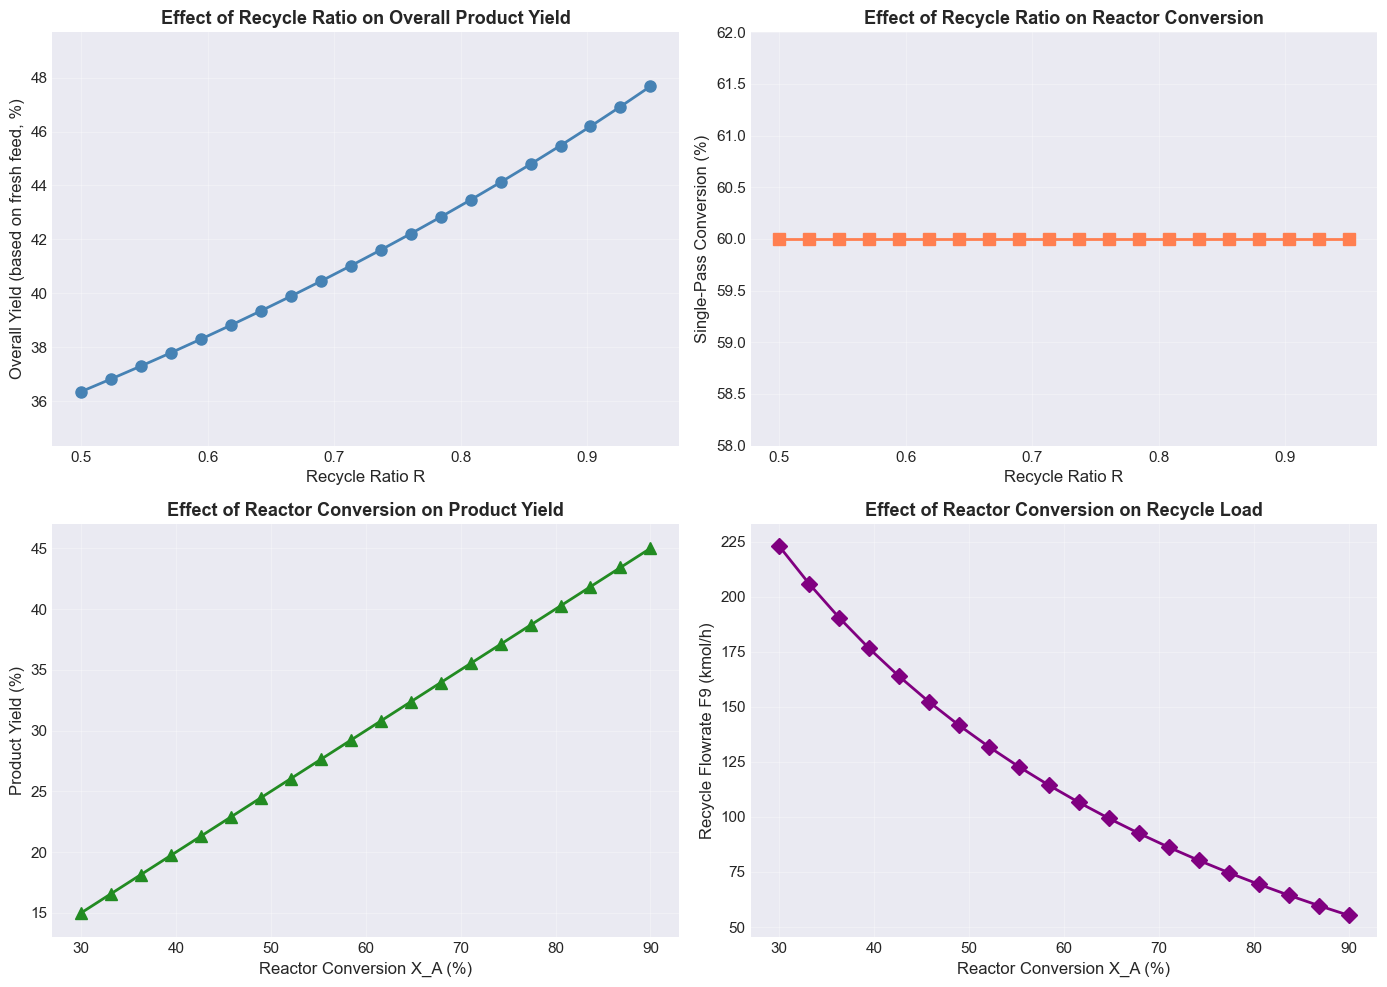


圖表說明:
  左上: 回流比增加 → 總產率提高（基於新鮮進料，更多未反應物回收）
  右上: 回流比增加 → 單次通過轉化率不變（反應器條件固定）
  左下: 反應轉化率增加 → 產品產率提高（單次通過效率提升）
  右下: 反應轉化率增加 → 循環流率降低（減少回收負荷）

重要提示:
  - 左上圖顯示『總產率』= 最終產品 P / 新鮮進料 A
  - 右上圖顯示『單次通過轉化率』（反應器內，不受回流比影響）
  - 單次通過產率 = 30.00% (恆定值 = X_A/2)


In [24]:
# 視覺化敏感度分析結果
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 圖 1: 回流比 vs 總產率（基於新鮮進料）
axes[0, 0].plot(R_values, product_yields, marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0, 0].set_xlabel('Recycle Ratio R', fontsize=12)
axes[0, 0].set_ylabel('Overall Yield (based on fresh feed, %)', fontsize=12)
axes[0, 0].set_title('Effect of Recycle Ratio on Overall Product Yield', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([min(product_yields)-2, max(product_yields)+2])

# 圖 2: 回流比 vs 單次通過轉化率（應為常數）
axes[0, 1].plot(R_values, overall_conversions, marker='s', linewidth=2, markersize=8, color='coral')
axes[0, 1].set_xlabel('Recycle Ratio R', fontsize=12)
axes[0, 1].set_ylabel('Single-Pass Conversion (%)', fontsize=12)
axes[0, 1].set_title('Effect of Recycle Ratio on Reactor Conversion', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([min(overall_conversions)-2, max(overall_conversions)+2])

# 圖 3: 反應轉化率 vs 產品產率
axes[1, 0].plot(X_A_values*100, product_yields_2, marker='^', linewidth=2, markersize=8, color='forestgreen')
axes[1, 0].set_xlabel('Reactor Conversion X_A (%)', fontsize=12)
axes[1, 0].set_ylabel('Product Yield (%)', fontsize=12)
axes[1, 0].set_title('Effect of Reactor Conversion on Product Yield', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([min(product_yields_2)-2, max(product_yields_2)+2])

# 圖 4: 反應轉化率 vs 循環流率
axes[1, 1].plot(X_A_values*100, recycle_flowrates, marker='D', linewidth=2, markersize=8, color='purple')
axes[1, 1].set_xlabel('Reactor Conversion X_A (%)', fontsize=12)
axes[1, 1].set_ylabel('Recycle Flowrate F9 (kmol/h)', fontsize=12)
axes[1, 1].set_title('Effect of Reactor Conversion on Recycle Load', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim([min(recycle_flowrates)-10, max(recycle_flowrates)+10])

plt.tight_layout()

# 儲存圖片
import os
output_dir = 'outputs/figs'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
fig_path = os.path.join(output_dir, 'Unit06_Example_06_Sensitivity_Analysis.png')
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"✓ 圖片已儲存至：{fig_path}")

plt.show()

print("\n圖表說明:")
print("  左上: 回流比增加 → 總產率提高（基於新鮮進料，更多未反應物回收）")
print("  右上: 回流比增加 → 單次通過轉化率不變（反應器條件固定）")
print("  左下: 反應轉化率增加 → 產品產率提高（單次通過效率提升）")
print("  右下: 反應轉化率增加 → 循環流率降低（減少回收負荷）")
print("\n重要提示:")
print(f"  - 左上圖顯示『總產率』= 最終產品 P / 新鮮進料 A")
print(f"  - 右上圖顯示『單次通過轉化率』（反應器內，不受回流比影響）")
print(f"  - 單次通過產率 = {product_yields_single[0]:.2f}% (恆定值 = X_A/2)")

✓ 圖片已儲存至：outputs/figs\Unit06_Example_06_Stream_Flowrates.png


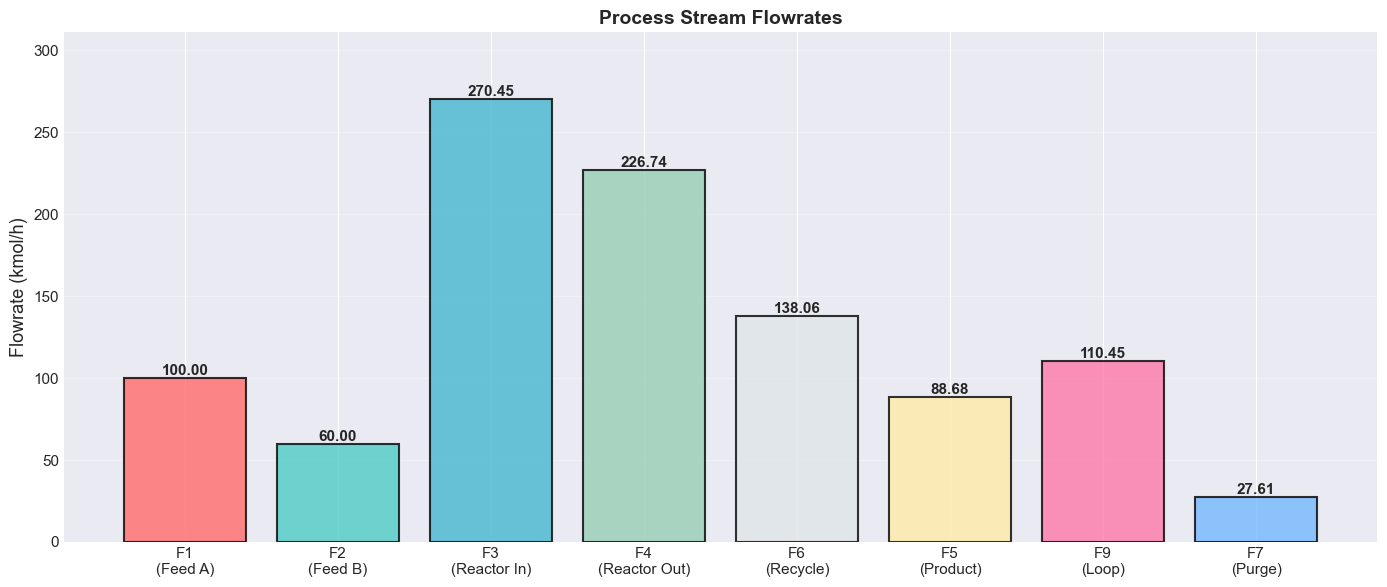


製程各股流流率總覽


In [25]:
# 繪製製程股流流率柱狀圖
stream_names = ['F1\n(Feed A)', 'F2\n(Feed B)', 'F3\n(Reactor In)', 'F4\n(Reactor Out)', 
                'F6\n(Recycle)', 'F5\n(Product)', 'F9\n(Loop)', 'F7\n(Purge)']
stream_flowrates = [F1, F2, F3_total, F4_total, F6_total, F5_total, F9_total, F7_total]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#DFE6E9', '#FFEAA7', '#FD79A8', '#74B9FF']

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(stream_names, stream_flowrates, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# 在柱狀圖上標注數值
for bar, flowrate in zip(bars, stream_flowrates):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{flowrate:.2f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Flowrate (kmol/h)', fontsize=13)
ax.set_title('Process Stream Flowrates', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, max(stream_flowrates) * 1.15])

plt.tight_layout()

# 儲存圖片
import os
output_dir = 'outputs/figs'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
fig_path = os.path.join(output_dir, 'Unit06_Example_06_Stream_Flowrates.png')
fig.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"✓ 圖片已儲存至：{fig_path}")

plt.show()

print("\n製程各股流流率總覽")

---
## 10. 總結

### 10.1 重點回顧

在本範例中，我們完成了：

1. **建立綜合化工製程的物料平衡模型**：
   - 整合反應、分離、混合、循環等多個單元操作
   - 處理循環流與分流的複雜系統

2. **將複雜製程問題轉化為線性聯立方程組**：
   - 選擇合適的未知數（10 個成分流率）
   - 建立獨立的物料平衡方程式（10 個方程式）
   - 形成矩陣形式 $\mathbf{Ax} = \mathbf{b}$

3. **使用 NumPy 與 SciPy 求解大型線性方程組**：
   - 驗證解的唯一性與正確性
   - 分析解的物理意義

4. **進行製程效率分析**：
   - 計算原料總轉化率、產品產率、回收率等關鍵指標
   - 驗證整體物料平衡

5. **執行敏感度分析**：
   - 探討回流比對產品產率與總轉化率的影響
   - 探討反應轉化率對製程效率與循環負荷的影響

### 10.2 工程實務洞察

**優化策略**：

1. **回流比優化**：
   - 提高回流比可提升產品產率與總轉化率
   - 但會增加循環流量，導致設備尺寸與能耗增加
   - 需要經濟分析找出最佳平衡點

2. **反應器改善**：
   - 提高反應轉化率可顯著提升產品產率
   - 同時降低循環流量，減少後續處理負擔
   - 可通過增大反應器體積、優化操作條件或使用高效催化劑達成

3. **分離系統設計**：
   - 分離效率直接影響產品純度與原料回收率
   - 高效分離可減少原料浪費與副產物處理成本

### 10.3 延伸學習

進階主題包括：

- **非線性製程系統**：考慮非線性反應動力學與相平衡
- **動態模擬**：非穩態操作的微分方程求解
- **製程最優化**：使用優化算法尋找最佳操作參數
- **經濟評估**：結合成本分析進行製程設計決策
- **製程控制**：設計控制系統維持穩定操作

In [26]:
# 最終總結報告
print("="*70)
print("綜合化工製程流程物料平衡分析 - 總結報告")
print("="*70)

print(f"\n【製程配置】")
print(f"  反應式: 2A + B → P + W")
print(f"  新鮮進料: A = {F1:.0f} kmol/h, B = {F2:.0f} kmol/h")
print(f"  反應轉化率: {X_A*100:.0f}%")
print(f"  回流比: {R*100:.0f}%")

print(f"\n【關鍵結果】")
print(f"  反應器進料總流率: {F3_total:.2f} kmol/h")
print(f"  產品 P 產量: {F5_P:.2f} kmol/h")
print(f"  循環流量: {F9_total:.2f} kmol/h")
print(f"  排放流量: {F7_total:.2f} kmol/h")

print(f"\n【製程效率】")
print(f"  原料 A 總轉化率: {A_conversion:.2f}%")
print(f"  產品 P 產率: {P_yield_based_on_A:.2f}%")
print(f"  未反應物回收率: {R*100:.2f}%")

print(f"\n【敏感度分析結論】")
print(f"  1. 回流比從 {R_values[0]:.0%} 提升至 {R_values[-1]:.0%}:")
overall_yield_results = results_R['P_yield_overall']
print(f"     → 總產率提升: {max(overall_yield_results) - min(overall_yield_results):.2f}% (基於新鮮進料)")
print(f"     → 單次通過產率: {product_yields_single[0]:.2f}% (恆定，由反應器決定)")
print(f"  2. 反應轉化率從 {X_A_values[0]:.0%} 提升至 {X_A_values[-1]:.0%}:")
print(f"     → 產品產率提升: {max(product_yields_2) - min(product_yields_2):.2f}%")
print(f"     → 循環流量降低: {max(recycle_flowrates) - min(recycle_flowrates):.2f} kmol/h")

print(f"\n【實務建議】")
print(f"  ✓ 提高回流比以改善原料利用率")
print(f"  ✓ 優化反應器操作以提升單次通過轉化率")
print(f"  ✓ 平衡回收率與設備成本的經濟效益")
print(f"  ✓ 定期檢驗分離系統效率以確保產品品質")

print("="*70)
print("分析完成！")
print("="*70)

綜合化工製程流程物料平衡分析 - 總結報告

【製程配置】
  反應式: 2A + B → P + W
  新鮮進料: A = 100 kmol/h, B = 60 kmol/h
  反應轉化率: 60%
  回流比: 80%

【關鍵結果】
  反應器進料總流率: 270.45 kmol/h
  產品 P 產量: 43.25 kmol/h
  循環流量: 110.45 kmol/h
  排放流量: 27.61 kmol/h

【製程效率】
  原料 A 總轉化率: 60.00%
  產品 P 產率: 30.00%
  未反應物回收率: 80.00%

【敏感度分析結論】
  1. 回流比從 50% 提升至 95%:
     → 總產率提升: 11.32% (基於新鮮進料)
     → 單次通過產率: 30.00% (恆定，由反應器決定)
  2. 反應轉化率從 30% 提升至 90%:
     → 產品產率提升: 30.00%
     → 循環流量降低: 167.68 kmol/h

【實務建議】
  ✓ 提高回流比以改善原料利用率
  ✓ 優化反應器操作以提升單次通過轉化率
  ✓ 平衡回收率與設備成本的經濟效益
  ✓ 定期檢驗分離系統效率以確保產品品質
分析完成！
